# Exploratory Data Analysis on Netflix Dataset

## Objective
Analyze Netflix dataset using Pandas, Matplotlib and Seaborn to identify trends and insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title             

In [4]:
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

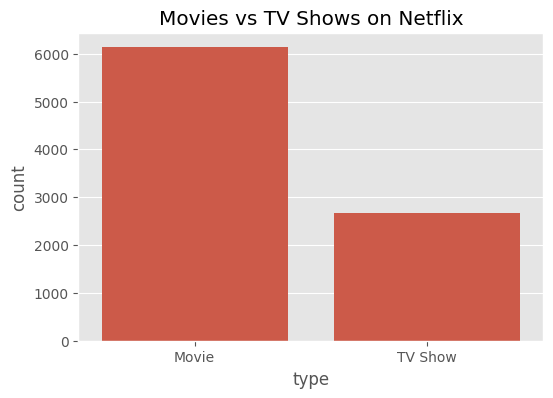

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")

plt.show()

Insight:
Netflix contains more Movies compared to TV Shows.

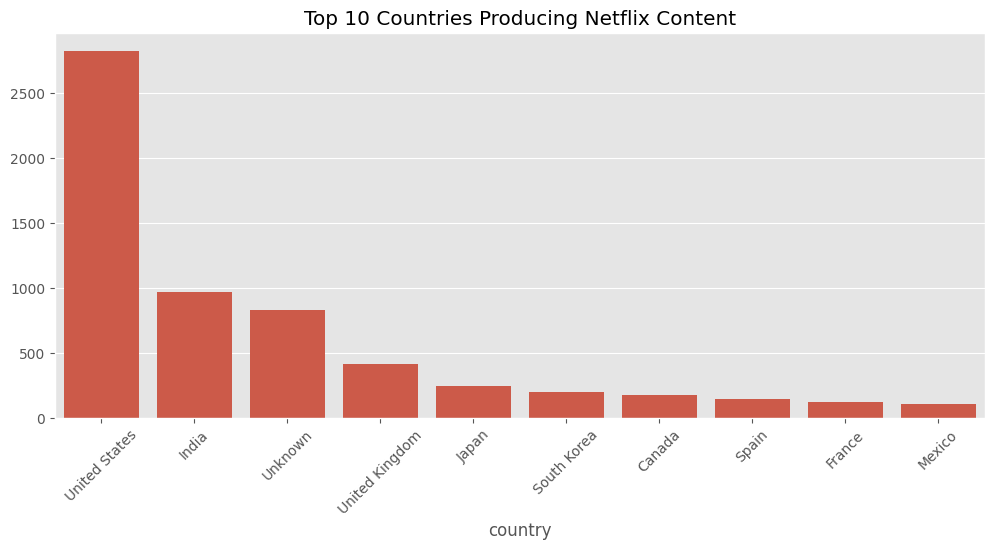

In [6]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_country.index,
y=top_country.values)

plt.xticks(rotation=45)

plt.title("Top 10 Countries Producing Netflix Content")

plt.show()

Insight:
United States produces the highest Netflix content.

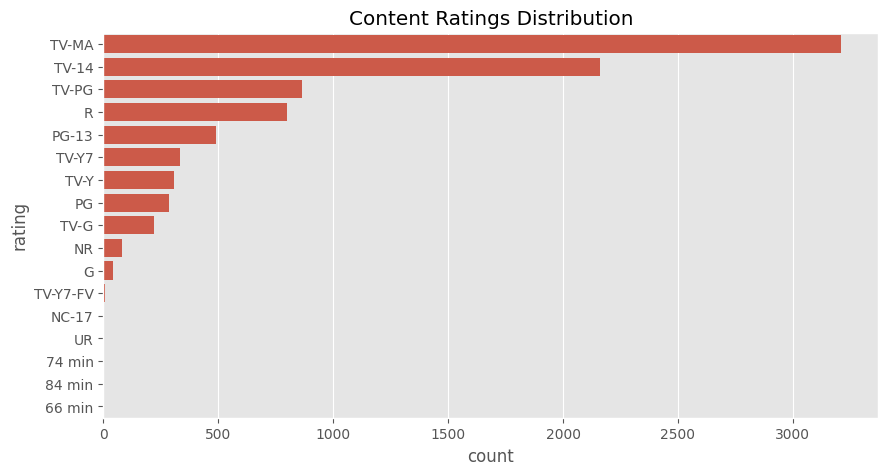

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(y='rating',
data=df,
order=df['rating'].value_counts().index)

plt.title("Content Ratings Distribution")

plt.show()

Insight:
TV-MA and TV-14 are the most common ratings.

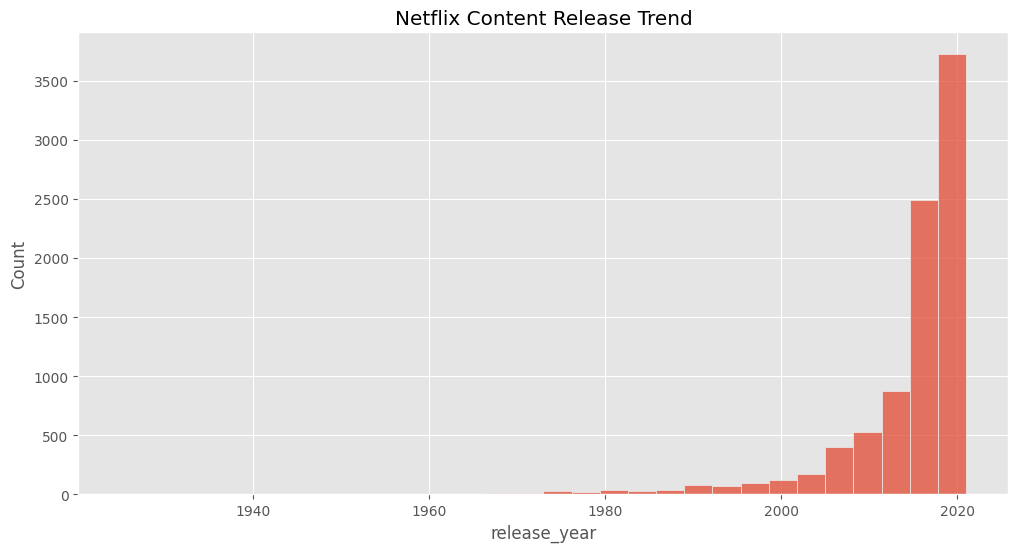

In [8]:
plt.figure(figsize=(12,6))

sns.histplot(df['release_year'],
bins=30)

plt.title("Netflix Content Release Trend")

plt.show()

Insight:
Netflix content increased rapidly after 2015.

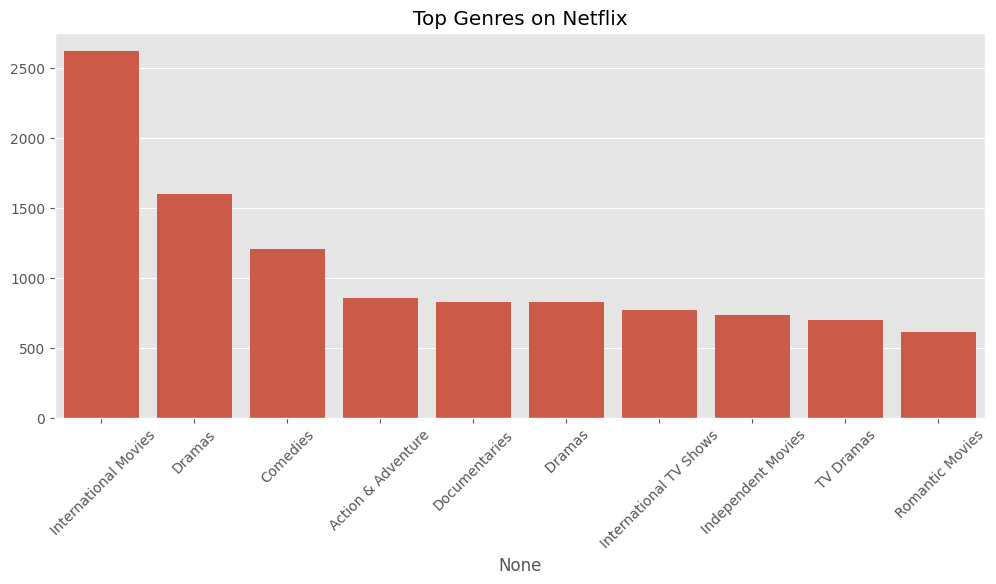

In [9]:
genres = df['listed_in'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_genres.index,
y=top_genres.values)

plt.xticks(rotation=45)

plt.title("Top Genres on Netflix")

plt.show()

Insight:
Drama and International Movies are the most popular genres.

In [10]:
print("Most content type:",
df['type'].mode()[0])

print("Most common rating:",
df['rating'].mode()[0])

print("Top country:",
df['country'].mode()[0])

Most content type: Movie
Most common rating: TV-MA
Top country: United States
